# Testing pyradiomics with DICOM and SEG

In [1]:
# imports

import os
from pathlib import Path
import SimpleITK as sitk
import numpy as np
import pydicom
from tqdm import tqdm
import matplotlib.pyplot as plt
from radiomics import featureextractor


Total amount of slices: 134


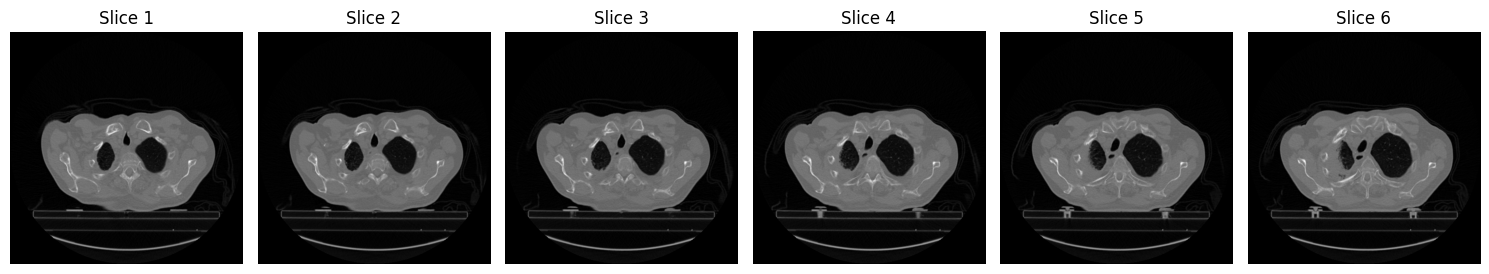

In [20]:
dcm_paths = Path(os.path.expanduser('~/Documents/Test-NSCLC/LUNG1-001/09-18-2008-StudyID-NA-69331/0.000000-NA-82046'))
seg_path = Path(os.path.expanduser('~/Documents/Test-NSCLC/LUNG1-001/09-18-2008-StudyID-NA-69331/300.000000-Segmentation-9.554'))

#seperate dicom files
#dcm_files = [f for f in dcm_paths.glob('*.dcm')]
dcm_files = sorted([f for f in dcm_paths.glob('*.dcm')])
print('Total amount of slices: {}'.format(len(dcm_files)))

slices = [pydicom.dcmread(f) for f in dcm_files[30:36]]
fig, axes = plt.subplots(1, len(slices), figsize=(15, 5))
for i, ds in enumerate(slices):
    img = ds.pixel_array
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(f"Slice {i+1}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()


In [14]:
# full dicom header 

ds = pydicom.dcmread(dcm_files[0])
print(ds)

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 206
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: CT Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.3.6.1.4.1.32722.99.99.307880158436639081057603825300678127628
(0002,0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.3.6.1.4.1.22213.1.143
(0002,0013) Implementation Version Name         SH: '0.5'
(0002,0016) Source Application Entity Title     AE: 'POSDA'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'AXIAL', 'CT_SOM5 SPI']
(0008,0016) SOP Class UID                       UI: CT Image Storage
(0008,0018) SOP Instance UID                    UI: 1.3.6.1.4.1.32722.99.99.3078801584366

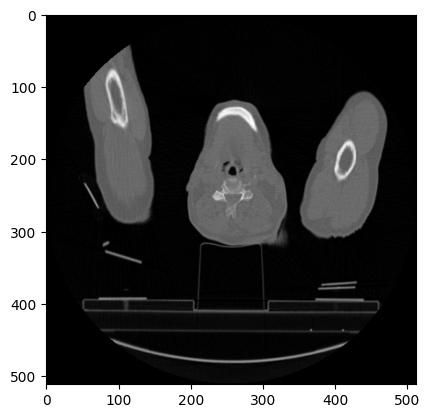

In [17]:
px, py = ds.PixelSpacing
img = ds.pixel_array
plt.imshow(img, cmap='gray')
plt.gca().set_aspect(py / px)
plt.show()


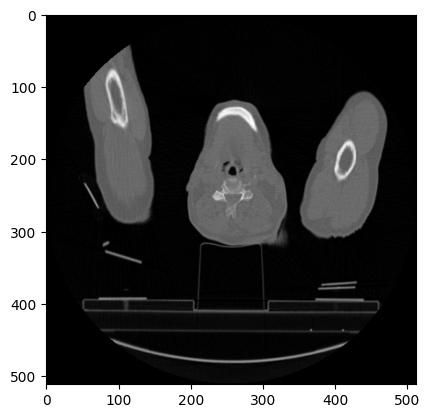

In [18]:
import scipy.ndimage as ndimage

px, py = ds.PixelSpacing
zoom_factor = [px/py, 1]  # adjust as needed

resampled = ndimage.zoom(img, zoom_factor)
plt.imshow(resampled, cmap='gray')
plt.show()
